In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cyvcf2 import VCF

base_dir = '/scratch/gpfs/AKEY/apfennig/LongHap/'
stats_pattern = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.stats.tsv'
eval_pattern = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.evaluation.tab'


stats_pattern_rare = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.rare.stats.tsv'
eval_pattern_rare = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.rare.evaluation.tab'

stats_pattern_complex = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.complex.stats.tsv'
eval_pattern_complex = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.complex.evaluation.tab'

stats_pattern_complex_rare = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.rare.complex.stats.tsv'
eval_pattern_complex_rare = base_dir + '{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.{tool}_phased.annotated.rare.complex.evaluation.tab'


samples_pop_mapping = {'HG00609': 'EAS', 'HG00658': 'EAS', 
           'HG00738': "AMR", 'HG01099': "AMR", 
           'HG02723': "AFR", 'HG02615': "AFR", 'HG002': "EUR"}
samples = ['HG00609', 'HG00658', 'HG00738', 'HG01099', 'HG02723', 'HG02615', 'HG002']
tools = ['LongHap Meth', 'LongHap']
chroms = np.arange(1, 23)
stats = {}
evaluation = {}

stats_rare = {}
evaluation_rare = {}

stats_complex = {}
evaluation_complex = {}

stats_complex_rare = {}
evaluation_complex_rare = {}

for sample in samples:
    stats[sample] = {}
    evaluation[sample] = {}
    
    stats_rare[sample] = {}
    evaluation_rare[sample] = {}
    
    stats_complex[sample] = {}
    evaluation_complex[sample] = {}
    
    stats_complex_rare[sample] = {}
    evaluation_complex_rare[sample] = {}
    for tool in tools:
        df_stats = pd.concat([pd.read_csv(stats_pattern.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        df_eval = pd.concat([pd.read_csv(eval_pattern.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        stats[sample][tool] = df_stats
        evaluation[sample][tool] = df_eval
        
        
        df_stats_rare = pd.concat([pd.read_csv(stats_pattern_rare.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        df_eval_rare = pd.concat([pd.read_csv(eval_pattern_rare.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        stats_rare[sample][tool] = df_stats_rare
        evaluation_rare[sample][tool] = df_eval_rare
        
        df_stats_complex = pd.concat([pd.read_csv(stats_pattern_complex.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        df_eval_complex = pd.concat([pd.read_csv(eval_pattern_complex.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        stats_complex[sample][tool] = df_stats_complex
        evaluation_complex[sample][tool] = df_eval_complex
        
        
        df_stats_complex_rare = pd.concat([pd.read_csv(stats_pattern_complex_rare.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        df_eval_complex_rare = pd.concat([pd.read_csv(eval_pattern_complex_rare.format(sample=sample, chrom=chrom, 
                                                               tool=tool.replace(' ', '_').lower()), 
                                          sep='\t') for chrom in chroms])
        stats_complex_rare[sample][tool] = df_stats_complex_rare
        evaluation_complex_rare[sample][tool] = df_eval_complex_rare

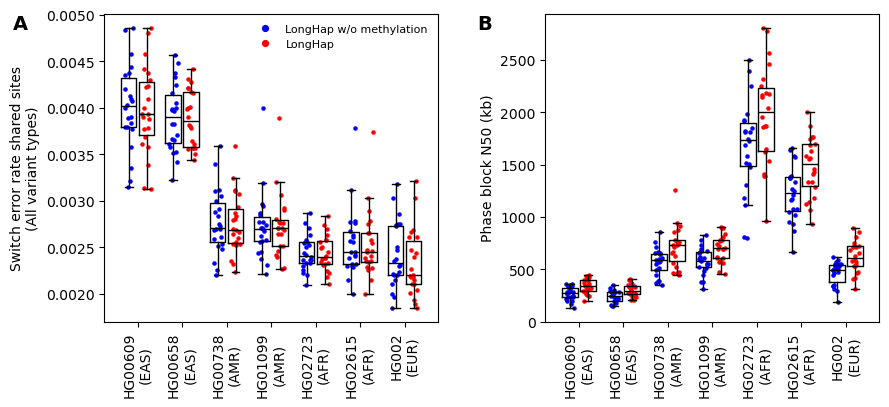

In [3]:
def plot_fraction_phased_vs_error_rate(eval_dict, stats_dict, tool, marker='o', ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    total_var = stats_dict['LongHap']['heterozygous_variants'].values.sum()
    chrom_var = stats_dict['LongHap']['heterozygous_variants'].values
    handles = []
    for tool in tools:
    
        var_phased = stats_dict[tool]['phased'].values
        total_phased = var_phased.sum()

        fracs_phased = var_phased / chrom_var
        xerr = np.array([[total_phased / total_var - np.percentile(fracs_phased, 2.5), 
                          np.percentile(fracs_phased, 97.5) - total_phased / total_var]]).T

        total_error = np.sum(eval_dict[tool]['all_switches'].values)
        chrom_error = eval_dict[tool]['all_switch_rate'].values
        yerr= np.abs([[total_error / total_phased - np.percentile(chrom_error, 2.5),
                         np.percentile(chrom_error, 97.5) - total_error / total_phased]]).T
        print(f'{tool}: {total_phased / total_var * 100} ({fracs_phased.min()}-{fracs_phased.max()}; {total_error / total_phased * 100}%)')
#     if tool == 'LongHap':
#         tool_name = 'LongHap w/o\nmethylation'
#     elif tool == 'LongHap Meth':
#         tool_name = 'LongHap'
#     elif tool == "WhatsHap + MethPhaser":
#         tool_name = "WhatsHap +\nMethPhaser"
#     else:
#         tool_name = tool
#     handles.append(Line2D([0], [0], ls='', marker=markers[tool], color=colors[tool], label=tool_name))
        ax.errorbar(total_phased / total_var, total_error / total_phased, xerr=xerr, yerr=yerr,
                   color=colors[tool], marker=marker, capsize=4)
#     ax.legend(handles=handles, loc='upper left', markerscale=0.7, frameon=False, labelspacing=0.3,
#              borderpad=0.1, handletextpad=0.3, fontsize=8, ncol=legend_col)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)
    return ax


fig = plt.figure(figsize=(10, 4))
gs = fig.add_gridspec(nrows=1, ncols=23)
ax0 = fig.add_subplot(gs[0, :10])
ax1 = fig.add_subplot(gs[0, 13:23])
# ax2 = fig.add_subplot(gs[0, 27:37])

longhap_err = [evaluation[sample]['LongHap'].all_switch_rate.values for sample in samples]
longhap_meth_err = [evaluation[sample]['LongHap Meth'].all_switch_rate.values for sample in samples]

longhap_n50s = [stats[sample]['LongHap'].block_n50.values / 1000 for sample in samples]
longhap_meth_n50s = [stats[sample]['LongHap Meth'].block_n50.values / 1000 for sample in samples]


ax0.boxplot(longhap_err, positions=np.arange(len(samples)) * 2 - 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax0.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 - 0.4, longhap_err[i], 
               color='blue', s=5)
    
ax0.boxplot(longhap_meth_err, positions=np.arange(len(samples)) * 2 + 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax0.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 + 0.4, longhap_meth_err[i], 
               color='red', s=5)

ax0.set_xticks(np.arange(len(samples)) * 2)
ax0.set_xticklabels([f'{s}\n({samples_pop_mapping[s]})' for s in samples], rotation=90)
ax0.set_ylabel('Switch error rate shared sites\n(All variant types)')

ax1.boxplot(longhap_n50s, positions=np.arange(len(samples)) * 2 - 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax1.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 - 0.4, longhap_n50s[i], 
               color='blue', s=5)
    
ax1.boxplot(longhap_meth_n50s, positions=np.arange(len(samples)) * 2 + 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax1.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 + 0.4, longhap_meth_n50s[i], 
               color='red', s=5)

ax1.set_xticks(np.arange(len(samples)) * 2)
ax1.set_xticklabels([f'{s}\n({samples_pop_mapping[s]})' for s in samples], rotation=90)
ax1.set_ylabel('Phase block N50 (kb)')

handles = [Line2D([0], [0], marker='o', ls='', color='blue', label="LongHap w/o methylation"),
           Line2D([0], [0], marker='o', ls='', color='red', label="LongHap")]
ax0.legend(handles=handles, loc='upper right', frameon=False, fontsize=8, markerscale=0.7)

ax0.set_xlim([-1.5, 13.5])
ax1.set_xlim([-1.5, 13.5])
ax0.annotate("A", (-0.275, 0.95), xycoords=ax0.transAxes, fontsize=14, fontweight='bold')

ax1.annotate("B", (-0.205, 0.95), xycoords=ax1.transAxes, fontsize=14, fontweight='bold')

fig.savefig('longhap_population_samples.png', bbox_inches='tight', dpi=600)
# for sample in samples:
#     ax2 = plot_fraction_phased_vs_error_rate(evaluation_complex[sample], stats_complex_rare[sample], 
#                                    tools, ax=ax2)

In [11]:
for s in samples:
    print(s, np.round(evaluation[s]['LongHap Meth'].all_switch_rate.min() * 100, 3), np.round(evaluation[s]['LongHap Meth'].all_switch_rate.max() * 100, 3))

HG00609 0.313 0.486
HG00658 0.343 0.442
HG00738 0.223 0.359
HG01099 0.227 0.389
HG02723 0.211 0.283
HG02615 0.199 0.374
HG002 0.185 0.321


In [12]:
for s in samples:
    print(s, np.round(stats[s]['LongHap Meth'].block_n50.mean() /1000, 3))

HG00609 341.484
HG00658 301.654
HG00738 714.048
HG01099 699.315
HG02723 1974.444
HG02615 1479.672
HG002 617.043


In [13]:
(1974.444 + 1479.672) / 2

1727.058

HG00609 -61 822
HG00658 -10 753
HG00738 -22 453
HG01099 3 441
HG02723 8 151
HG02615 -29 225
HG002 -202 680


Text(-0.1, 1.0, 'B')

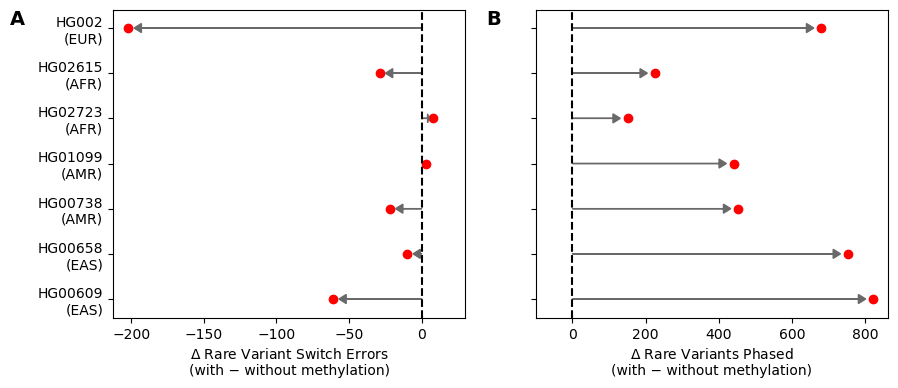

In [4]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

for i, sample in enumerate(samples):
    longhap_meth_err = evaluation_rare[sample]['LongHap Meth'].all_switches.sum()# / evaluation_rare[samples[0]]['LongHap Meth'].all_assessed_pairs.sum()
    longhap_err = evaluation_rare[sample]['LongHap'].all_switches.sum()# / evaluation_rare[samples[0]]['LongHap'].all_assessed_pairs.sum()
    longhap_meth_phased = stats_rare[sample]['LongHap Meth'].phased.sum()
    longhap_phased = stats_rare[sample]['LongHap'].phased.sum()
    print(sample, longhap_meth_err - longhap_err, longhap_meth_phased - longhap_phased)
    ax[0].scatter(longhap_meth_err - longhap_err, i, color='red')
    if longhap_meth_err - longhap_err < 0:
        ax[0].arrow(0, i, longhap_meth_err - longhap_err + 4 , 0, length_includes_head=True, head_width=0.2, 
                    head_length=5, facecolor='dimgrey', edgecolor='dimgrey')
    else:
        ax[0].arrow(0, i, longhap_meth_err - longhap_err - 3, 0, length_includes_head=True, head_width=0.2, 
            head_length=1, facecolor='dimgrey', edgecolor='dimgrey')
        
    ax[1].scatter(longhap_meth_phased - longhap_phased, i, color='red')
    ax[1].arrow(0, i, longhap_meth_phased - longhap_phased - 20, 0, length_includes_head=True, head_width=0.2, 
            head_length=20, facecolor='dimgrey', edgecolor='dimgrey')
ax[0].set_xlim([ax[0].get_xlim()[0], 30])

ax[1].set_xlim([-100, ax[1].get_xlim()[1]])
ax[0].set_yticks(np.arange(0, len(samples)))
ax[0].set_yticklabels([f'{s}\n({samples_pop_mapping[s]})' for s in samples])
ax[0].axvline(0, ls='--', color='black')
ax[1].axvline(0, ls='--', color='black')
ax[0].set_xlabel(r'$\Delta$ ' + 'Rare Variant Switch Errors\n(with − without methylation)')
ax[1].set_xlabel(r'$\Delta$ ' + 'Rare Variants Phased\n(with − without methylation)')

ax[0].annotate("A", (-0.25, 1.0), xycoords=ax[0].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

ax[1].annotate("B", (-0.1, 1.0), xycoords=ax[1].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

In [19]:
for sample in samples:
    print(sample, evaluation_rare[sample]['LongHap Meth'].all_switches.sum(), evaluation_rare[sample]['LongHap'].all_switches.sum())

HG00609 5694 5755
HG00658 5917 5927
HG00738 3614 3636
HG01099 3666 3663
HG02723 1965 1957
HG02615 2496 2525
HG002 3591 3793


In [18]:
for sample in samples:
    print(sample, stats_rare[sample]['LongHap Meth'].phased.sum(), stats_rare[sample]['LongHap'].phased.sum())

HG00609 105191 104369
HG00658 102865 102112
HG00738 107882 107429
HG01099 108539 108098
HG02723 292531 292380
HG02615 282096 281871
HG002 78296 77616


In [4]:
def get_variants_in_region(vcf, chrom, region_start, region_end):
    pos = []
    allele_a = []
    allele_b = []
    genotypes = []
    allele_frequency = []
    for variant in vcf(f'chr{chrom}:{region_start}-{region_end}'):
        gt = variant.genotypes[0]
        if gt[0] != gt[1] and gt[2]:
            alleles = [variant.REF] + variant.ALT
            pos.append(variant.POS)
            allele_a.append(alleles[sorted(gt[:2])[0]])
            allele_b.append(alleles[sorted(gt[:2])[1]])
            genotypes.append(gt)
            try:
                allele_frequency.append(variant.INFO['AF'])
            except KeyError:
                allele_frequency.append(np.nan)
    return np.array(pos), np.array(allele_a), np.array(allele_b), np.array(genotypes), np.array(allele_frequency)


target_gene = 'STXBP2'
chrom = '19'
region_start = 7597501
region_end = 7648756
sample='HG00609'
hprc = VCF(f'{base_dir}{sample}/dipcall/asm.dip.normalized.vcf.gz')
longhap = VCF(f'{base_dir}{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.longhap_phased.annotated.vcf.gz')
longhap_meth = VCF(f'{base_dir}{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.longhap_meth_phased.annotated.vcf.gz')



            
hprc_pos, hprc_allele_a, hprc_allele_b, hprc_gt, _ = get_variants_in_region(hprc, chrom, region_start, 
                                                                         region_end)
longhap_pos, longhap_allele_a, longhap_allele_b, longhap_gt, longhap_af = get_variants_in_region(longhap, chrom,
                                                                                     region_start, 
                                                                                     region_end)

(longhap_meth_pos, longhap_meth_allele_a, 
 longhap_meth_allele_b, longhap_meth_gt, _) = get_variants_in_region(longhap_meth, chrom,
                                                                  region_start, region_end)


overlapping_hprc_pos = np.isin(hprc_pos, longhap_pos)
overlapping_longhap_pos = np.isin(longhap_pos, hprc_pos)


hprc_pos = hprc_pos[overlapping_hprc_pos]
hprc_allele_a = hprc_allele_a[overlapping_hprc_pos]
hprc_allele_b = hprc_allele_b[overlapping_hprc_pos]
hprc_gt = hprc_gt[overlapping_hprc_pos]

longhap_pos = longhap_pos[overlapping_longhap_pos]
longhap_allele_a = longhap_allele_a[overlapping_longhap_pos]
longhap_allele_b = longhap_allele_b[overlapping_longhap_pos]
longhap_gt = longhap_gt[overlapping_longhap_pos]
longhap_af = longhap_af[overlapping_longhap_pos]

longhap_meth_pos = longhap_meth_pos[overlapping_longhap_pos]
longhap_meth_allele_a = longhap_meth_allele_a[overlapping_longhap_pos]
longhap_meth_allele_b = longhap_meth_allele_b[overlapping_longhap_pos]
longhap_meth_gt = longhap_meth_gt[overlapping_longhap_pos]

concordant_variant_calls = (hprc_allele_a == longhap_allele_a) & (hprc_allele_b == longhap_allele_b) 
hprc_pos = hprc_pos[concordant_variant_calls]
hprc_allele_a = hprc_allele_a[concordant_variant_calls]
hprc_allele_b = hprc_allele_b[concordant_variant_calls]
hprc_gt = hprc_gt[concordant_variant_calls]

longhap_pos = longhap_pos[concordant_variant_calls]
longhap_allele_a = longhap_allele_a[concordant_variant_calls]
longhap_allele_b = longhap_allele_b[concordant_variant_calls]
longhap_gt = longhap_gt[concordant_variant_calls]
longhap_af = longhap_af[concordant_variant_calls]


longhap_meth_pos = longhap_meth_pos[concordant_variant_calls]
longhap_meth_allele_a = longhap_meth_allele_a[concordant_variant_calls]
longhap_meth_allele_b = longhap_meth_allele_b[concordant_variant_calls]
longhap_meth_gt = longhap_meth_gt[concordant_variant_calls]

[W::hts_idx_load3] The index file is older than the data file: /scratch/gpfs/AKEY/apfennig/LongHap/HG00609/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr19.longhap_phased.annotated.vcf.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /scratch/gpfs/AKEY/apfennig/LongHap/HG00609/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr19.longhap_meth_phased.annotated.vcf.gz.tbi


CAMSAP3 1
MIR6792 2
XAB2 3
PET100 1
AC008763.2 2
PCP2 4
AC008763.1 3
STXBP2 1


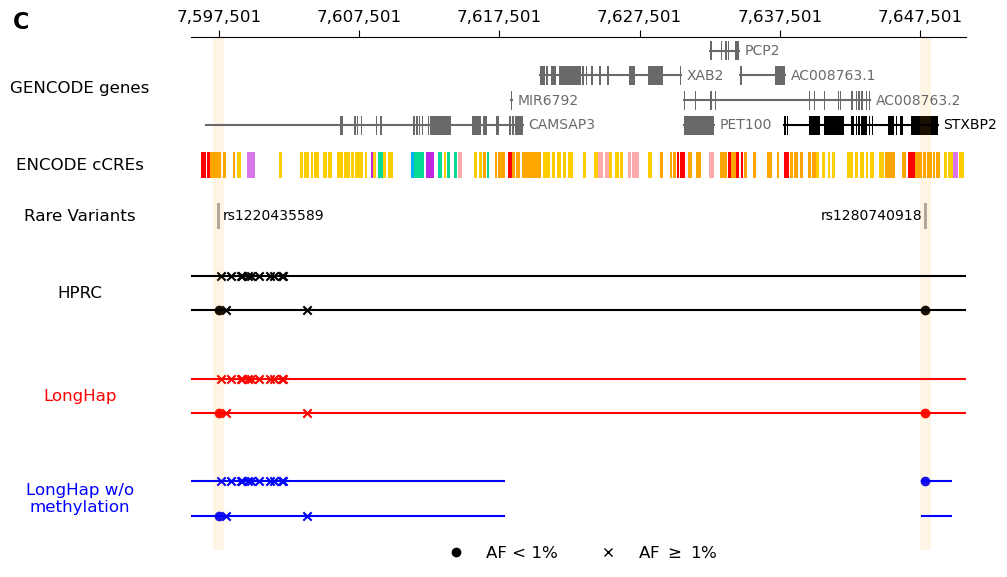

In [194]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
# gff3 = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/reference/chm13.draft_v2.0.gene_annotation.gff3',
#                     sep='\t', usecols=[0, 2, 3, 4, 8], names=['chrom', 'element', 'start', 'end', 'attributes'], 
#                     skiprows=1, engine='pyarrow')

# gff3 = gff3[(gff3.chrom == f'chr{chrom}') & (gff3.end > region_start) & (gff3.start < region_end)]
# exons = gff3[gff3.element == 'exon']
# genes = gff3[gff3.element == 'gene']
# genes['gene_name'] = [attribute.split(';')[0].split('=')[1] for attribute in genes.attributes]
# exons['gene_name'] = [attribute.split('gene_name=')[1].split(';')[0] for attribute in exons.attributes]
# exons = exons[exons.gene_name == target_gene]
# genes = genes[genes.gene_name == target_gene]

# cCREs = pd.read_csv(f'{base_dir}reference/cCREs_STXBP2_hs1.bed', sep='\t', 
#                     names=['chrom', 'start', 'end', 'rgb'])


longhap_blocks = pd.read_csv(f'{base_dir}{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.longhap_blocks.bed',
                             sep='\t', names=['chrom', 'start', 'end'])
longhap_meth_blocks = pd.read_csv(f'{base_dir}{sample}/longhap/deepvariant_sniffles_hifi_hs1.minimap2.chr{chrom}.longhap_meth_blocks.bed',
                             sep='\t', names=['chrom', 'start', 'end'])

final_genotypes = np.vstack([hprc_gt[:, 0], hprc_gt[:, 1],
                             longhap_meth_gt[:, 0],  longhap_meth_gt[:, 1], 
                             longhap_gt[:, 0], longhap_gt[:, 1]])

fig = plt.figure(figsize=(10, 10))
plt.subplots_adjust(hspace=0)
gs = gridspec.GridSpec(15, 1, figure=fig)
ax0 = fig.add_subplot(gs[:2, :])
ax7 = fig.add_subplot(gs[2:3, :])

ax1 = fig.add_subplot(gs[3:4, :])
ax2 = fig.add_subplot(gs[4:6, :])
ax3 = fig.add_subplot(gs[6:8, :])
ax4 = fig.add_subplot(gs[8:10, :])



prev_end = {1: 0}
for row, gene in genes.iterrows():
    i = 1
    while i in prev_end and prev_end[i] > gene['start']:
        i += 1
    prev_end[i] = gene['end'] + 3000
    print(gene['gene_name'], i)
    if gene['gene_name'] != target_gene:
        color='dimgrey'
    else:
        color='black'
    ax0.text(gene['end'] + 400, i * 4 + 1.5, gene['gene_name'], ha='left', va='center', fontsize=10, 
             color=color)

    ax0.plot([gene['start'], gene['end']], [i * 4 + 1.5, i * 4 + 1.5], color=color)
    
    c_exons = exons[exons.gene_name == gene['gene_name']]

    for idx, exon in c_exons.iterrows():

        patch = patches.Rectangle((exon['start'], i * 4), exon['end'] - exon['start'], 3,
                                 facecolor=color)
        ax0.add_patch(patch)
        
for row, cre in cCREs.iterrows():
    patch = patches.Rectangle((cre['start'], 4), cre['end'] - cre['start'], 2,
                                 facecolor=[int(r) / 255 for r in cre['rgb'].split(',')])
    ax7.add_patch(patch)

rare_vars = []
y_vals = np.sort(np.concatenate([np.arange(final_genotypes.shape[0] // 2) * 3, 
                                 np.arange(final_genotypes.shape[0] // 2) * 3 + 1]))
for i, (ax, color, blocks) in enumerate(zip([ax2, ax2, ax3, ax3, ax4, ax4], 
                                    ['black', 'black', 'red', 'red', 'blue', 'blue'],
                                    [[(region_start - 2000, region_end + 2000)],
                                     [(region_start - 2000, region_end + 2000)],
                                     longhap_meth_blocks[(longhap_meth_blocks.end >= region_start - 20000) & 
                                                         (longhap_meth_blocks.start <= region_end + 20000)].values[:, 1:].tolist(),
                                     longhap_meth_blocks[(longhap_meth_blocks.end >= region_start - 20000) & 
                                                         (longhap_meth_blocks.start <= region_end + 20000)].values[:, 1:].tolist(),
                                     longhap_blocks[(longhap_blocks.end >= region_start - 20000) & 
                                                    (longhap_blocks.start <= region_end + 20000)].values[:, 1:].tolist(),
                                     longhap_blocks[(longhap_blocks.end >= region_start - 20000) & 
                                                    (longhap_blocks.start <= region_end + 20000)].values[:, 1:].tolist()])):
    gt = final_genotypes[i]
    
    pos = longhap_pos[(gt > 0) & ~np.isnan(longhap_af)]
    af = longhap_af[(gt > 0) & ~np.isnan(longhap_af)]
    
    for p, a in zip(pos, af):
        if a < 0.01 and ~np.isnan(a):
            patch = patches.Rectangle((p - 100, 4), 200, 2, facecolor='darkgrey')
            ax1.add_patch(patch)
    for block in blocks:
        ax.plot([block[0] - 200, block[1]], [i % 2, i % 2], color=color)
    ax.scatter(pos[af >= 0.01], np.repeat(y_vals[i % 2], pos[af >= 0.01].shape[0]), marker='x', 
               color=color)
    ax.scatter(pos[af < 0.01], np.repeat(y_vals[i % 2], pos[af < 0.01].shape[0]), marker='o', color=color)

ax0.spines[:].set_visible(False)
ax0.spines['top'].set_visible(True)
ax0.set_yticks([])
ax0.set_yticklabels([])
ax0.set_ylabel('GENCODE genes', fontsize=12, rotation=0, labelpad=80, verticalalignment='center')

ax0.set_xticks(np.arange(region_start, region_end + 10000, 10000))
ax0.set_xticklabels([f'{tick:,}' for tick in np.arange(region_start, region_end + 10000, 10000)],
                    fontsize=12)
ax0.tick_params(
    top=True, labeltop=True,
    bottom=False, labelbottom=False,
    direction='out', length=5
)
ax0.xaxis.set_visible(True)
# ax0.xaxis.set_label_position('top')
# ax0.set_title(f'chr{chrom} (T2T)')

ax0.set_xlim([region_start - 2000, region_end + 2000])
ax1.set_xlim([region_start- 2000, region_end+ 2000])
ax2.set_xlim([region_start- 2000, region_end+ 2000])
ax3.set_xlim([region_start- 2000, region_end+ 2000])
ax4.set_xlim([region_start- 2000, region_end+ 2000])

ax7.set_xlim([region_start- 2000, region_end+ 2000])

ax1.set_ylabel('Rare Variants', fontsize=12, rotation=0, labelpad=80, verticalalignment='center')
ax2.set_ylabel(f'HPRC', fontsize=12, rotation=0, labelpad=80, verticalalignment='center')
ax3.set_ylabel(f'LongHap', fontsize=12, rotation=0, labelpad=80, verticalalignment='center', color='red')
ax4.set_ylabel('LongHap w/o\nmethylation', fontsize=12, rotation=0, labelpad=80, verticalalignment='center',
              color='blue')
ax7.set_ylabel('ENCODE cCREs', fontsize=12, rotation=0, labelpad=80, verticalalignment='center')


ax1.set_ylim([3, 7])
ax2.set_ylim([-1, 2])
ax3.set_ylim([-1, 2])
ax4.set_ylim([-1, 2])

ax7.set_ylim([3, 7])


ax1.spines[:].set_visible(False)
ax2.spines[:].set_visible(False)
ax3.spines[:].set_visible(False)
ax4.spines[:].set_visible(False)

ax7.spines[:].set_visible(False)


ax1.set_yticks([])
ax1.set_yticklabels([])
ax2.set_yticks([])
ax2.set_yticklabels([])
ax3.set_yticks([])
ax3.set_yticklabels([])
ax4.set_yticks([])
ax4.set_yticklabels([])


ax7.set_yticks([])
ax7.set_yticklabels([])
ax1.set_xticks([])
ax1.set_xticklabels([])
ax2.set_xticks([])
ax2.set_xticklabels([])
ax3.set_xticks([])
ax3.set_xticklabels([])
ax4.set_xticks([])
ax4.set_xticklabels([])
ax7.set_xticks([])
ax7.set_xticklabels([])
# ax6.set_xticks([])
# ax6.set_xticklabels([])
handles = [Line2D([0], [0], marker='o', ls='', color='black', label='AF < 1%'),
           Line2D([0], [0], marker='x', ls='', color='black',  label=r'AF $\geq$ 1%')]
ax4.legend(handles=handles, frameon=False, bbox_to_anchor=(0.5, 0.2), loc='upper center', fontsize=12, ncol=2)
ax0.annotate("C", (-0.23, 1.25), xycoords=ax0.transAxes, fontsize=16, fontweight='bold', va='top')

ax1.text(7597501 + 300, 5, 'rs1220435589', ha='left', va='center', fontsize=10)
ax1.text(7647863 - 200, 5, 'rs1280740918', ha='right', va='center', fontsize=10)

ax0.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax1.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax2.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax3.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax4.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax7.axvspan(7597501-400, 7597501+400, facecolor='orange', alpha=0.1)
ax0.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)
ax1.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)
ax2.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)
ax3.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)
ax4.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)
ax7.axvspan(7647863-400, 7647863+400, facecolor='orange', alpha=0.1)

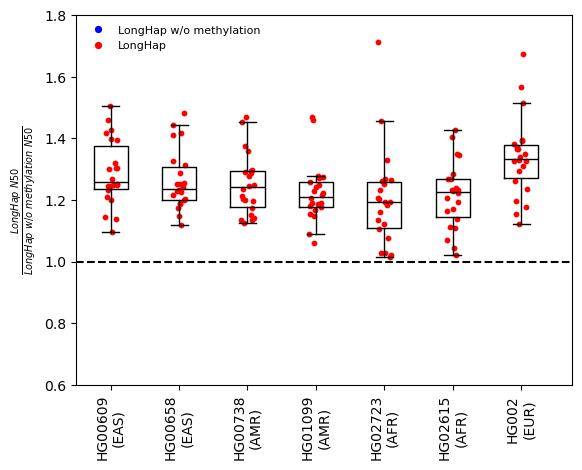

In [61]:
fig, ax = plt.subplots()
longhap_n50s = [stats[sample]['LongHap'].block_n50.values / 1000 for sample in samples]
longhap_meth_n50s = [stats[sample]['LongHap Meth'].block_n50.values / 1000 for sample in samples]

ax.boxplot([longhap_meth_n50s[i] / longhap_n50s[i] for i in range(len(samples))], 
            positions=np.arange(len(samples)) * 2, widths=1,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2, longhap_meth_n50s[i] / longhap_n50s[i], 
               color='red', s=10)
    

ax.set_xticks(np.arange(len(samples)) * 2)
ax.set_xticklabels([f'{s}\n({samples_pop_mapping[s]})' for s in samples], rotation=90)
ax.set_ylabel(r'$\frac{LongHap\ N50}{LongHap\ w/o\ methylation\ N50}$')
ax.set_xlim([-1, len(samples) * 2 - 0.5])
ax.set_ylim([0.6, 1.8])
ax.axhline(1, ls='--', color='black')


handles = [Line2D([0], [0], marker='o', ls='', color='blue', label="LongHap w/o methylation"),
           Line2D([0], [0], marker='o', ls='', color='red', label="LongHap")]
ax.legend(handles=handles, loc='upper left', frameon=False, fontsize=8, markerscale=0.7)

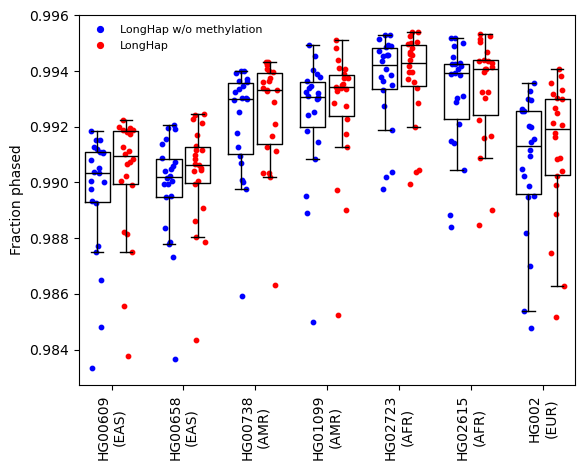

In [43]:
fig, ax = plt.subplots()
longhap_phased_fracs = [stats[sample]['LongHap'].phased_fraction.values for sample in samples]
longhap_meth_phased_fracs = [stats[sample]['LongHap Meth'].phased_fraction.values for sample in samples]

ax.boxplot(longhap_phased_fracs, positions=np.arange(len(samples)) * 2 - 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 - 0.4, longhap_phased_fracs[i], 
               color='blue', s=10)
    
ax.boxplot(longhap_meth_phased_fracs, positions=np.arange(len(samples)) * 2 + 0.4, widths=0.7,
           medianprops={"color": 'black'}, showfliers=False)
for i in range(len(samples)):
    ax.scatter(np.random.uniform(-0.2, 0.2, chroms.shape[0]) + i * 2 + 0.4, longhap_meth_phased_fracs[i], 
               color='red', s=10)

ax.set_xticks(np.arange(len(samples)) * 2)
ax.set_xticklabels([f'{s}\n({samples_pop_mapping[s]})' for s in samples], rotation=90)
ax.set_ylabel('Fraction phased')
handles = [Line2D([0], [0], marker='o', ls='', color='blue', label="LongHap w/o methylation"),
           Line2D([0], [0], marker='o', ls='', color='red', label="LongHap")]
ax.legend(handles=handles, loc='upper left', frameon=False, fontsize=8, markerscale=0.7)